In [1]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from scipy.stats import binned_statistic

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
randoms=fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_new.fits')[1].read()
randoms =randoms[randoms['DEC']>-30]


In [3]:
data={}
data['full'] = Table(fitsio.FITS('../table_match_final.fits')[1].read())
data['north'] = Table(fitsio.FITS(f'../../FP_CUTS/table_north_unique.fits')[1].read())
data['south'] = Table(fitsio.FITS(f'../../FP_CUTS/table_south_unique.fits')[1].read())

In [ ]:
colnames = [colname for colname in randoms.dtype.names if ('PSF' in colname) or ('GALDEPTH' in colname)  or ('MASKBITS' in colname) or ('NOBS' in colname) or ('EBV' in colname) or ('STARDENS' in colname) or ('HPXPIXEL' in colname) or ('MW_TRANSMISSION' in colname) or  ('FRACAREA' in colname) or ('FRACMASKED' in colname) or ('FRACFLUX' in colname) or ('FRACIN' in colname) ] 


# Randomly sample 20000 points
n_sample = min(50_000_000, len(randoms))
indices = np.random.choice(len(randoms), size=n_sample, replace=False)

ra_array = randoms['RA'][indices]
dec_array = randoms['DEC'][indices]
randoms_sampled = randoms[indices]



nside = 256

counts = np.bincount(pix, minlength=npix)  
fracarea = counts / counts.max()



In [ ]:
def pixel_median(ra_array, dec_array,values,nside = 256):
    theta = np.radians(90.0 - dec_array)
    phi = np.radians(ra_array)
    pix = hp.ang2pix(nside, theta, phi,nest=True)
    npix  = hp.nside2npix(nside)
    pixarea = hp.nside2pixarea(nside, degrees=True)  # in square degrees
    order = np.argsort(pix)
    pix_sorted = pix[order]
    _, idx = np.unique(pix_sorted, return_index=True)
    idx = np.append(idx,len(pix_sorted))
    arr = values[order]
    out = np.full(npix, np.nan)
    for i in range(len(idx)-1):
        start, end = idx[i], idx[i+1]
        p = pix_sorted[start]
        out[p] = np.median(arr[start:end])
    return out

In [152]:
# colnames
# for val in ['EBV']:
#     dat = randoms[val][indices]
#     # Create map with mean EBV per pixel
#     hpx_map = np.zeros(npix, dtype=float)
#     hpx_map[:] = hp.UNSEEN
#     for pix in np.unique(pix_indices):
#         mask = pix_indices == pix
#         hpx_map[pix] = np.mean(dat[mask])
#     hp.mollview(hpx_map, cmap='jet', unit=f"{val}", title=f"{val} Sky Map (nside={nside})")
#     hp.graticule()
#     plt.show()

In [170]:
len(randoms['EBV'])

79567985

In [208]:
median_vals = {}
for val in ['EBV']:  
    medians, _, _ = binned_statistic(
            pix, randoms_sampled[val], statistic='median', bins=npix, range=[0, npix]
        )
    median_vals[val] = medians
    print('Done with ', val)
     

Done with  EBV


In [214]:
median_map = {}
for val in colnames:
    median_map[val] = pixel_median(randoms_sampled[val])
    print('Done with ', val)

# PSFDEPTH_G_map = pixel_median(randoms["PSFDEPTH_G"])
# PSFDEPTH_R_map = pixel_median(randoms["PSFDEPTH_R"])
# PSFDEPTH_Z_map = pixel_median(randoms["PSFDEPTH_Z"])

# PSFSIZE_G_map  = pixel_median(randoms["PSFSIZE_G"])
# PSFSIZE_R_map  = pixel_median(randoms["PSFSIZE_R"])
# PSFSIZE_Z_map  = pixel_median(randoms["PSFSIZE_Z"])

# GALDEPTH_G_map = pixel_median(randoms["GALDEPTH_G"])
# GALDEPTH_R_map = pixel_median(randoms["GALDEPTH_R"])
# GALDEPTH_Z_map = pixel_median(randoms["GALDEPTH_Z"])



Done with  NOBS_G
Done with  NOBS_R
Done with  NOBS_Z
Done with  PSFDEPTH_G
Done with  PSFDEPTH_R
Done with  PSFDEPTH_Z
Done with  GALDEPTH_G
Done with  GALDEPTH_R
Done with  GALDEPTH_Z
Done with  PSFDEPTH_W1
Done with  PSFDEPTH_W2
Done with  PSFSIZE_G
Done with  PSFSIZE_R
Done with  PSFSIZE_Z
Done with  MASKBITS
Done with  EBV
Done with  HPXPIXEL


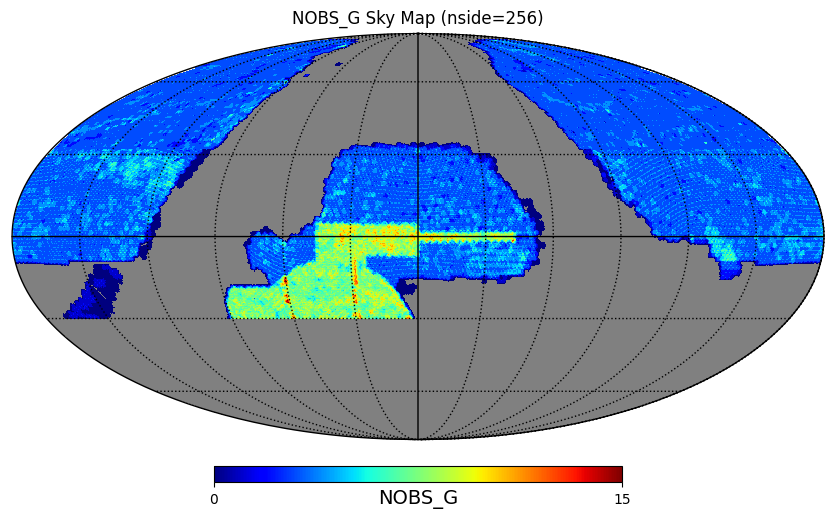

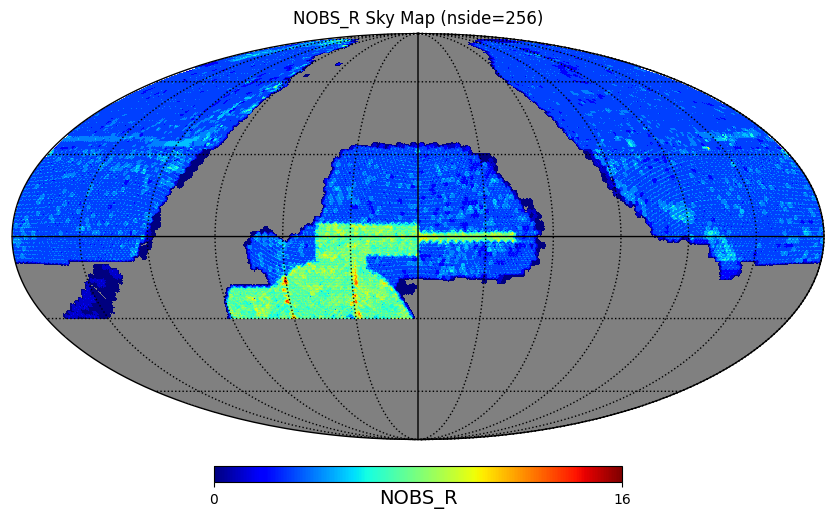

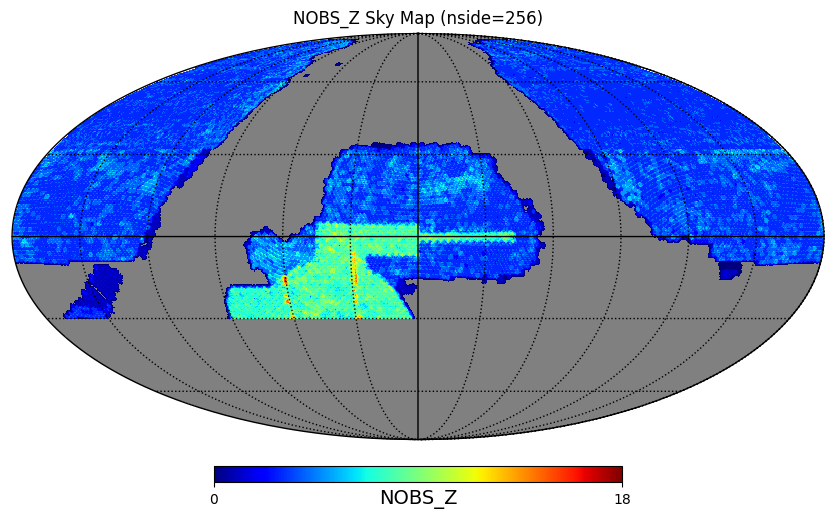

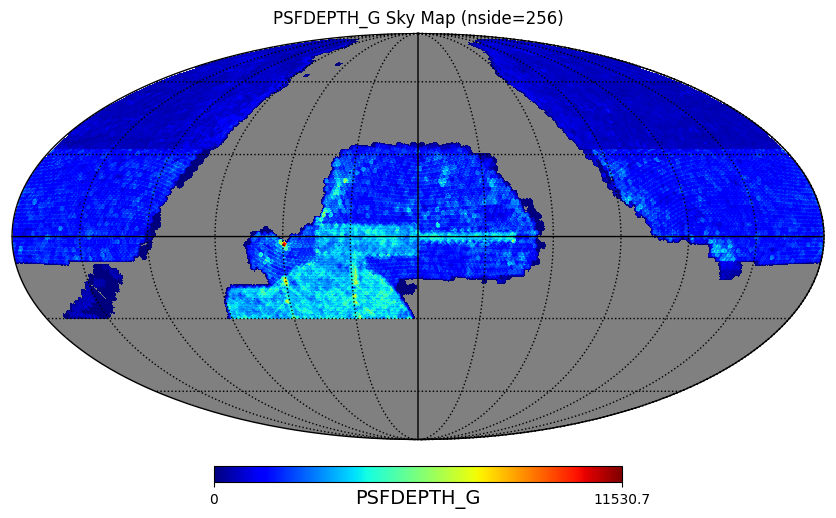

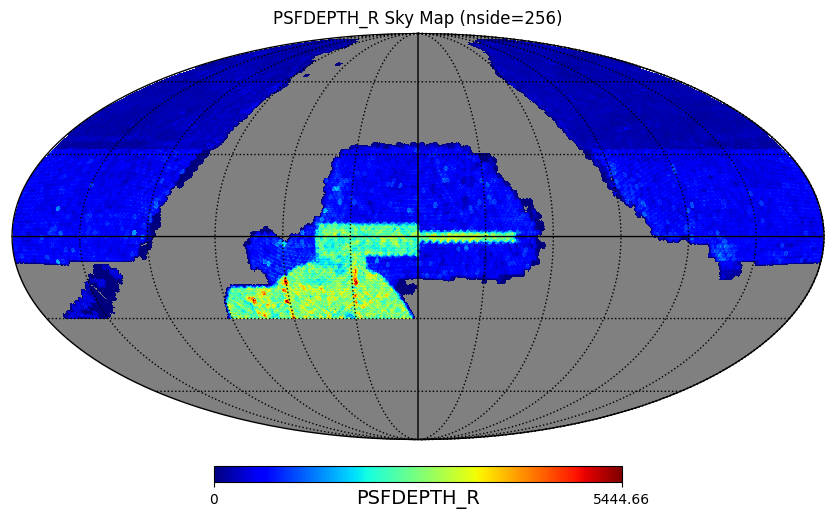

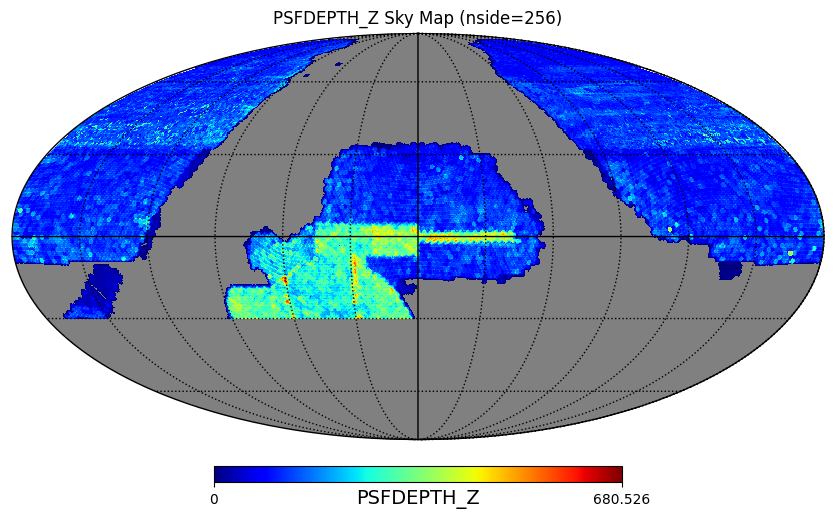

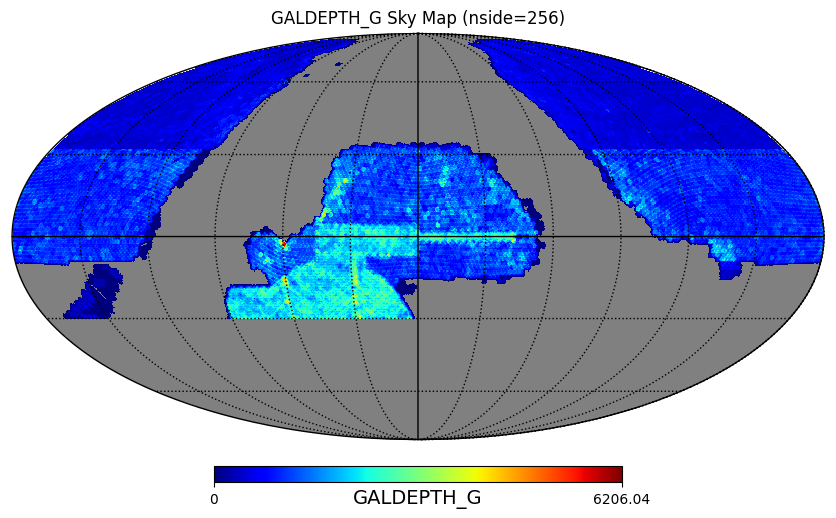

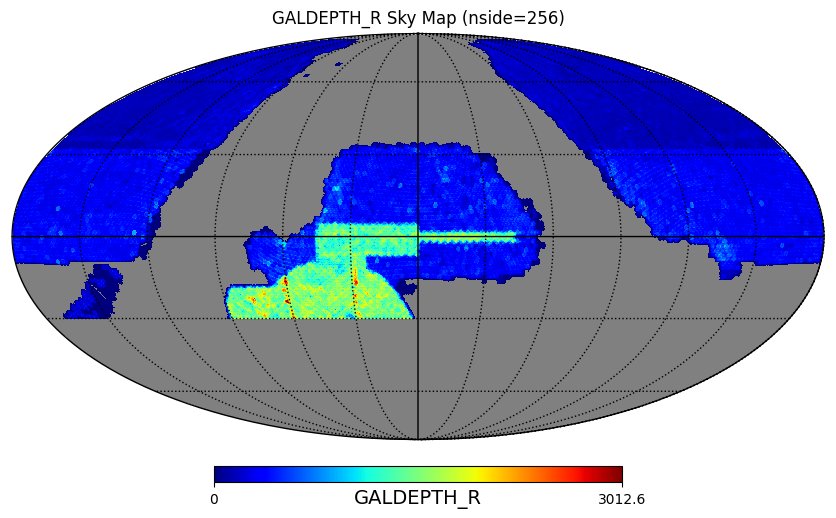

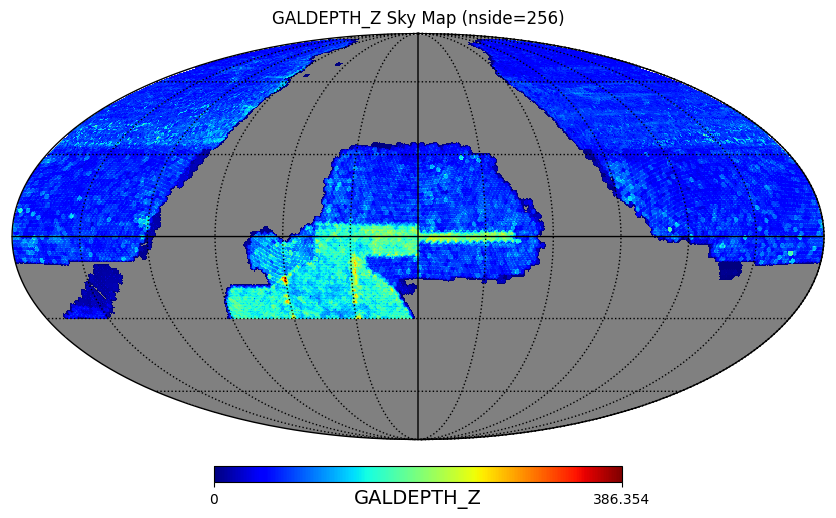

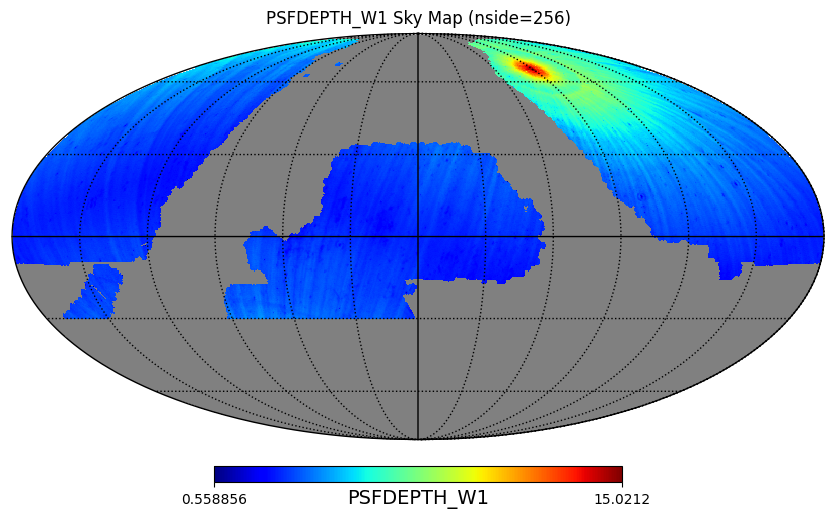

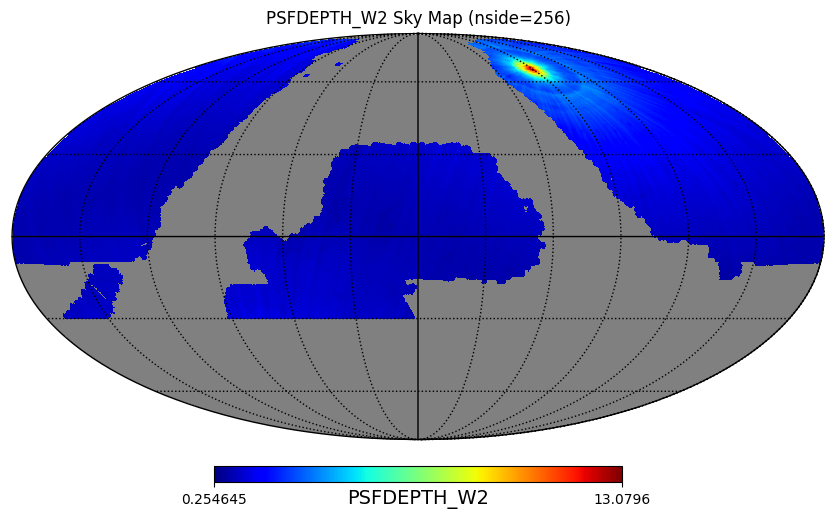

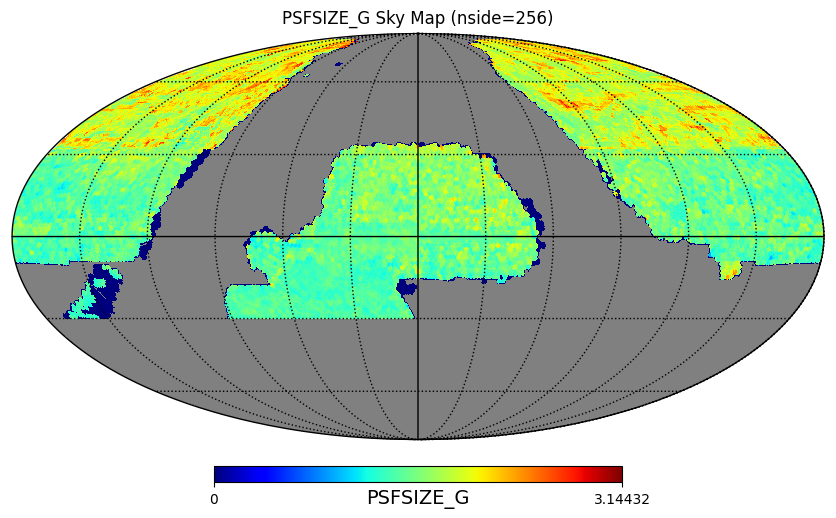

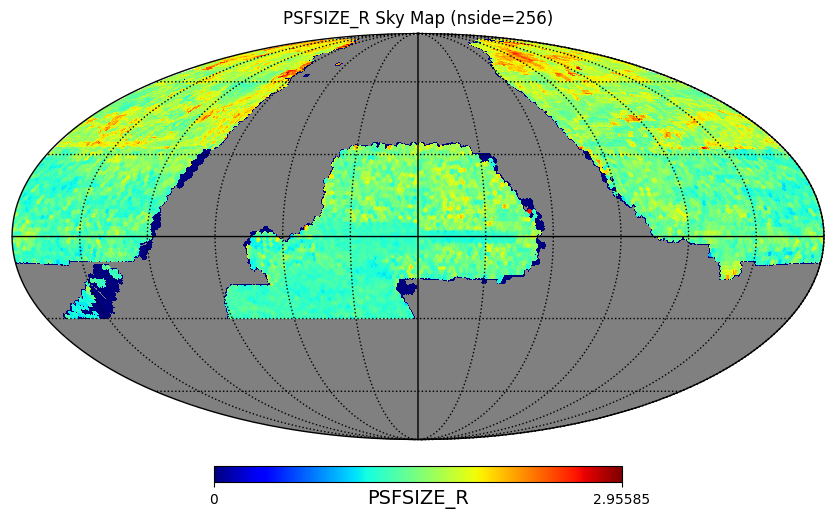

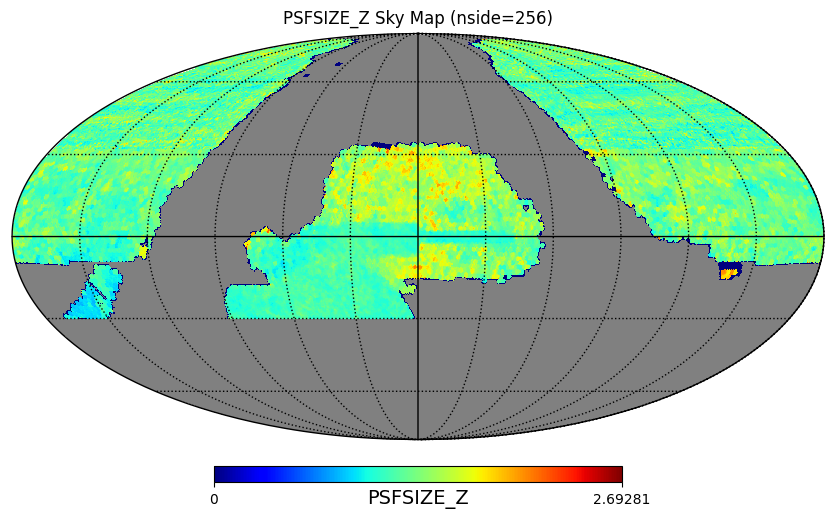

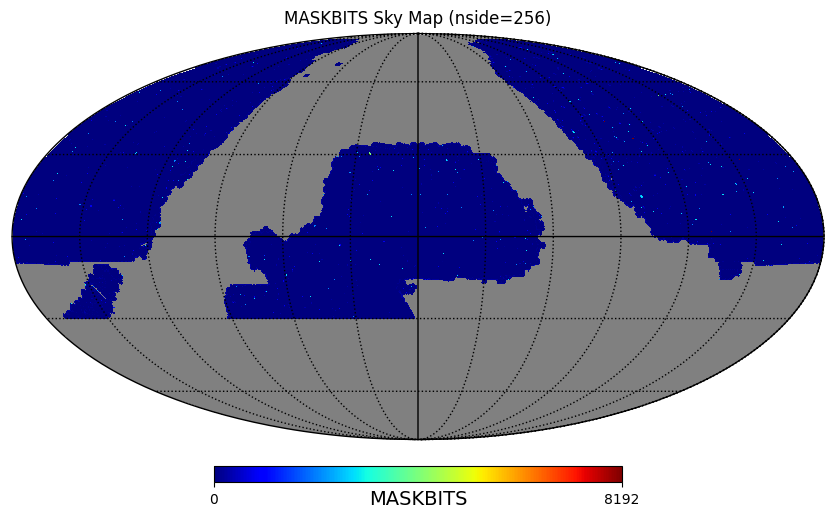

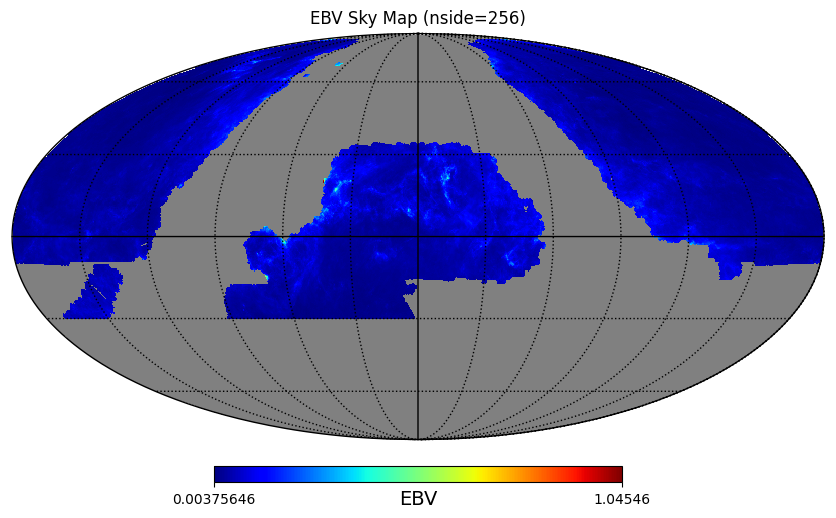

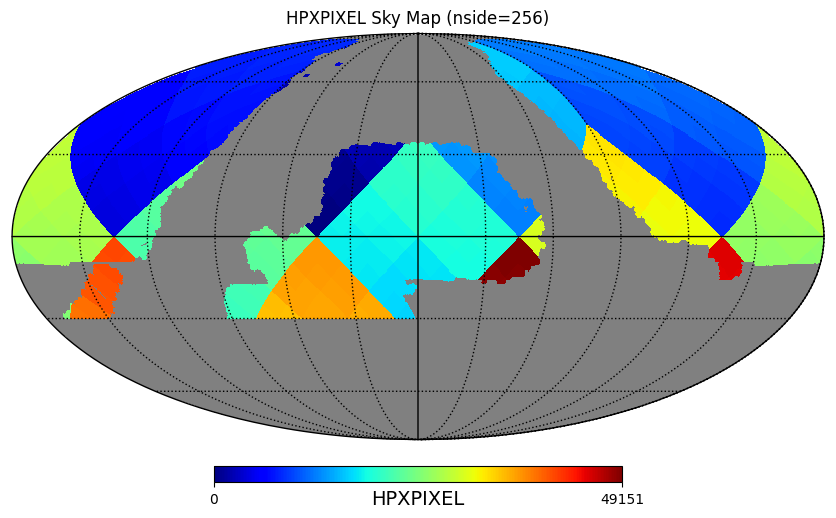

In [217]:
import os
os.makedirs('imaging_systematics_maps', exist_ok=True)
for val in colnames:
    hp.mollview(median_map[val], cmap='jet', unit=f"{val}", title=f"{val} Sky Map (nside={nside})", nest=True)
    hp.graticule()
    plt.savefig(f'imaging_systematics_maps/{val}_nside{nside}_full.png')
    plt.show()




In [189]:
 EBV_map[339]

nan

(array([], dtype=int64),)

In [118]:
ra_full,dec_full = data['full'][['RA','DEC']].to_pandas().values.T

pix_full  = hp.ang2pix(nside, np.radians(90.0 - dec_full), np.radians(ra_full),nest=True)

counts_full = np.bincount(pix_full, minlength=npix)
full_density = counts_full / pixarea  # objects per square degree 